<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/Impact_Energy_Based_Prediction_Model_for_Copper_Tube_Inner_Diameter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Library loading completed.

Raw data


,Risk Factor,mass_kg,velocity_ms,Energy_J,Energy_calc_J,DA_obs_mm,HA_obs_mm
0,"40kg, 1.4m/s",40,1.4,39,39.20,4.81,5.45
1,"60kg, 1.7m/s",60,1.7,87,86.70,3.76,4.48
2,"65kg, 1.8m/s",65,1.8,100,105.30,3.46,4.18
3,"70kg, 1.9m/s",70,1.9,126,126.35,3.15,3.87
4,"80kg, 2.0m/s",80,2.0,160,160.00,2.67,3.45



Regression Result

Energy-based equation
DA [mm] = 19.6229 × E^(-0.3800)
HA [mm] = 16.7560 × E^(-0.3034)

Mass-velocity-based equation
DA [mm] = 25.5362 × m^(-0.3800) × v^(-0.7600)
HA [mm] = 20.6779 × m^(-0.3034) × v^(-0.6068)

Actual vs Predicted


,Risk Factor,DA Actual,DA Predicted,DA Error [%],HA Actual,HA Predicted,HA Error [%]
0,39,4.81,4.876952,1.391943,5.45,5.513453,1.164274
1,87,3.76,3.595288,-4.380629,4.48,4.322138,-3.523700
2,100,3.46,3.409971,-1.445923,4.18,4.143317,-0.877593
3,126,3.15,3.123268,-0.848624,3.87,3.862732,-0.187802
4,160,2.67,2.852226,6.824938,3.45,3.592658,4.135008



Accuracy metrics


,Metric,DA,HA
0,R²,0.973549,0.977723
1,RMSE [mm],0.1167,0.1007
2,MAE [mm],0.0981,0.0816


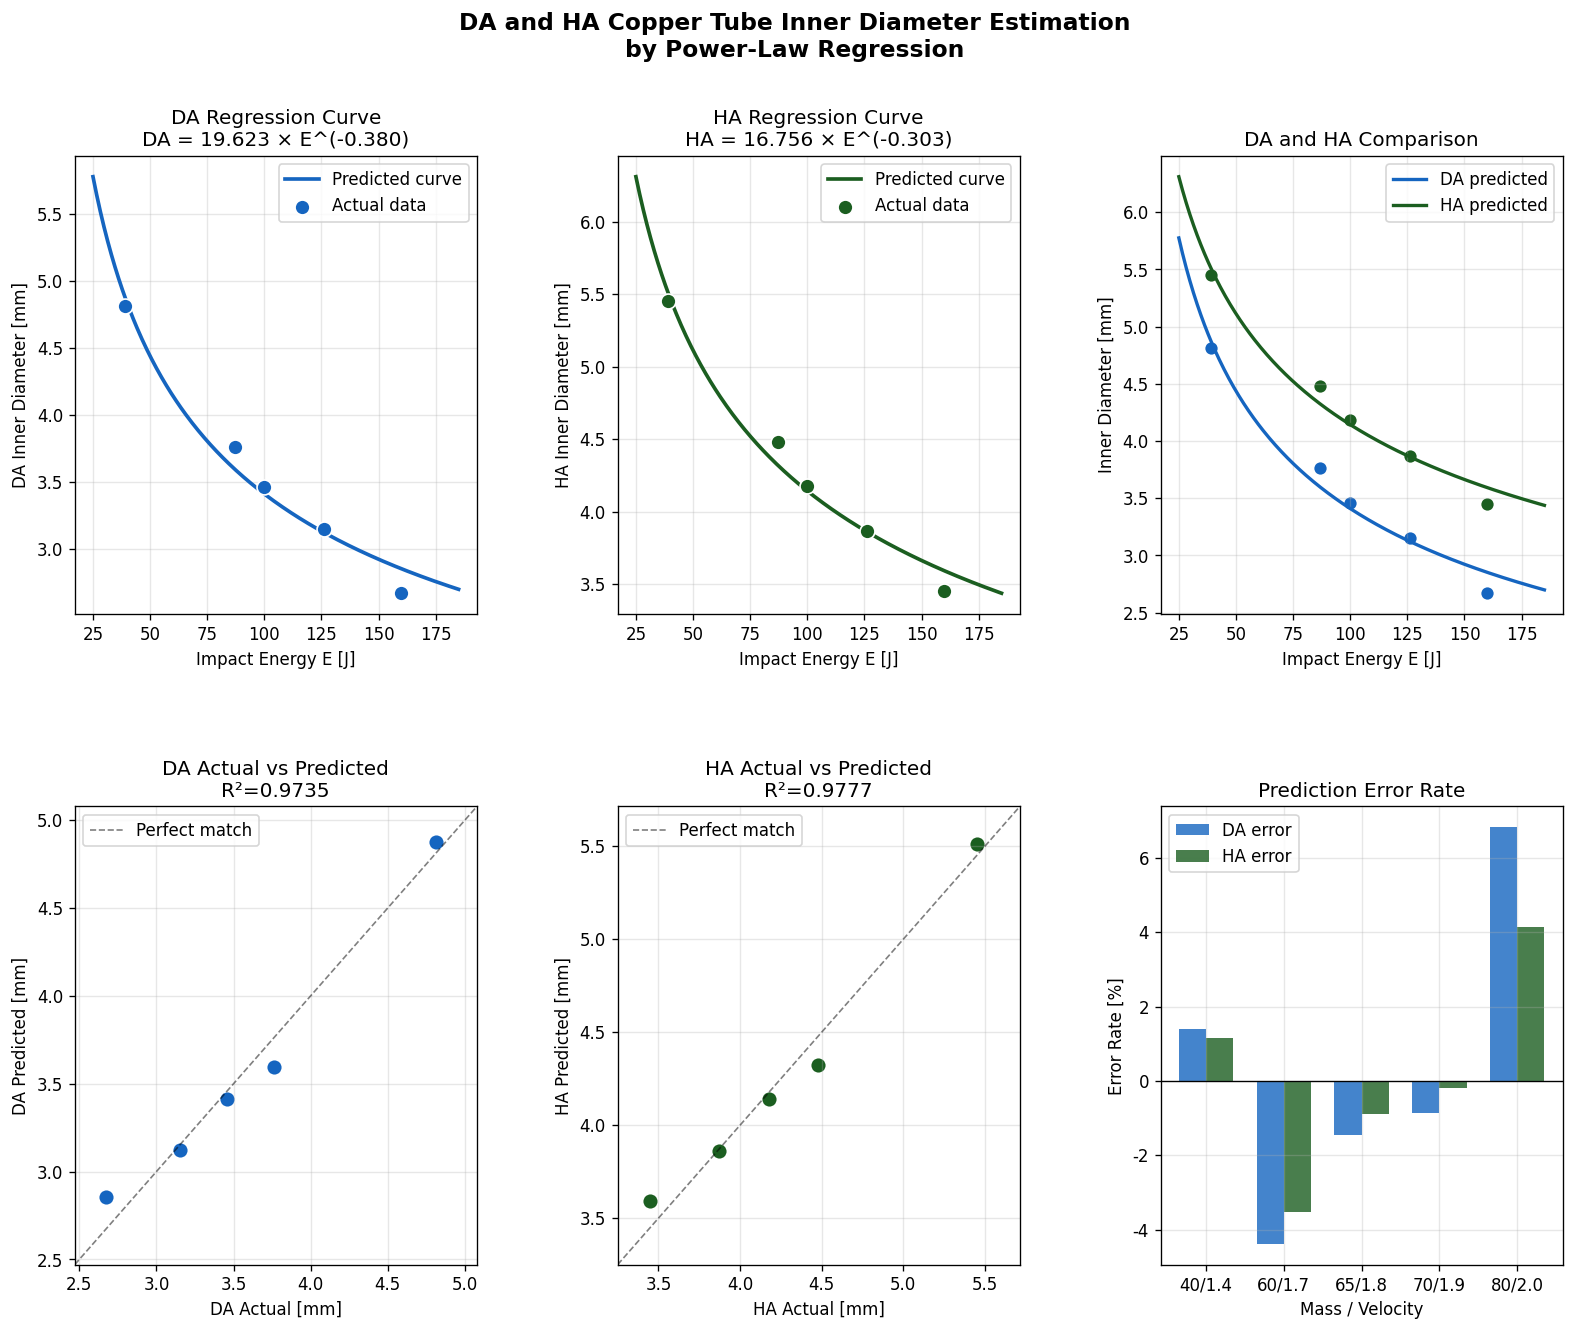


Graph saved: pipe_diameter_analysis.png


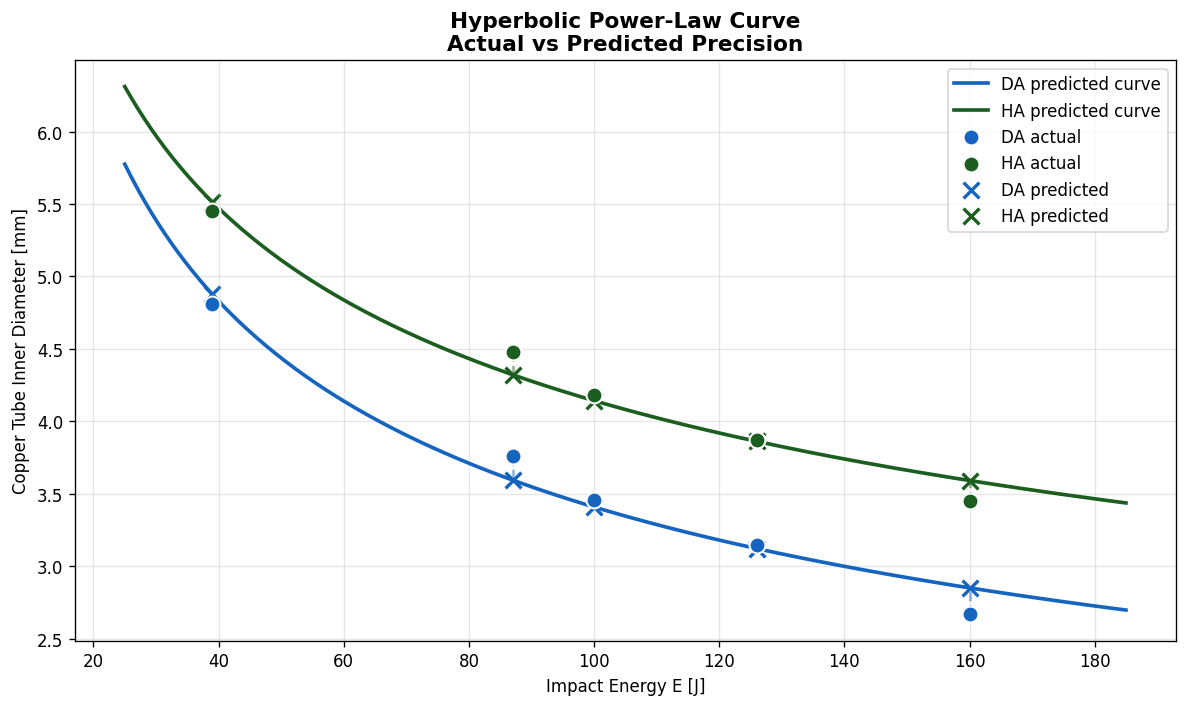

Graph saved: hyperbolic_precision_comparison.png

Estimation result


,Risk Factor,Energy [J],DA Estimated [mm],HA Estimated [mm]
0,"40kg, 1.4m/s",39.2,4.867,5.505
1,"70kg, 1.9m/s",126.3,3.120,3.859
2,"50kg, 1.6m/s",64.0,4.040,4.744
3,"100kg, 2.5m/s",312.5,2.212,2.932
4,"120kg, 2.0m/s",240.0,2.445,3.177


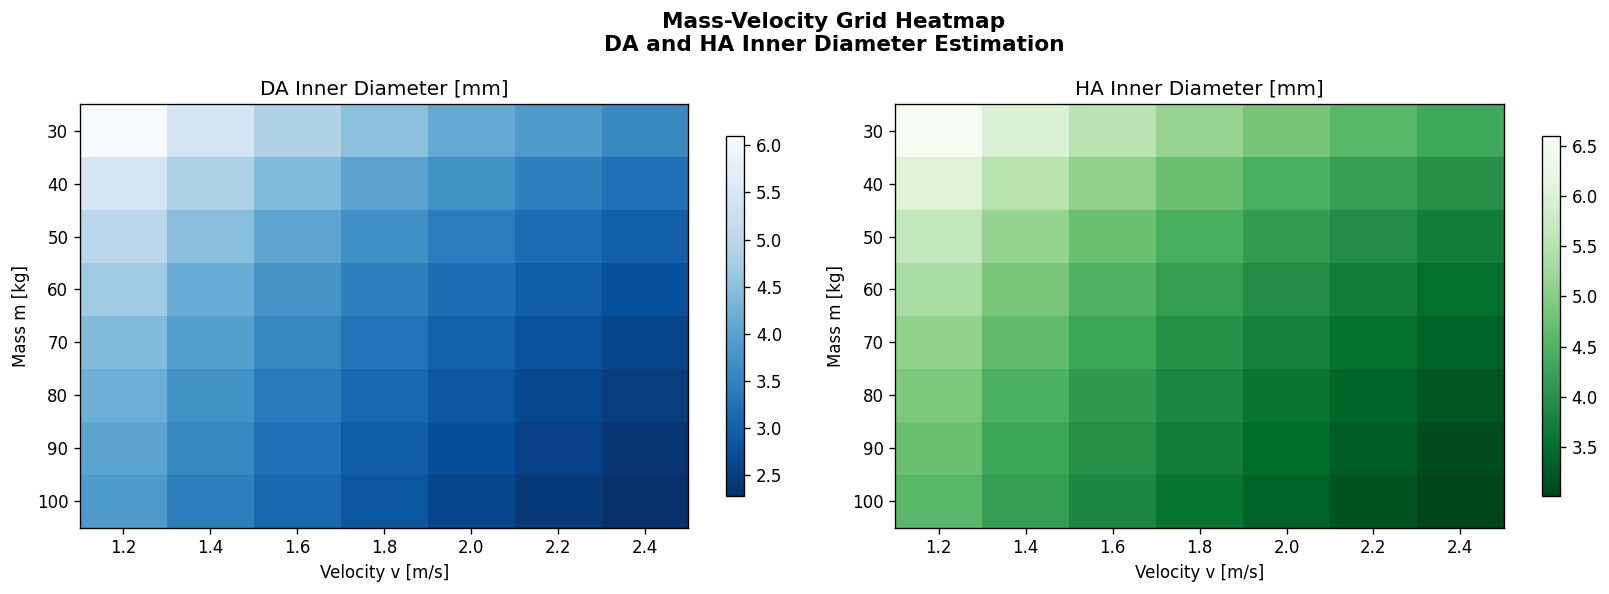

Graph saved: pipe_heatmap.png

Final Equation Summary
DA = 19.623 × E^(-0.380)
HA = 16.756 × E^(-0.303)

DA = 25.536 × m^(-0.380) × v^(-0.760)
HA = 20.678 × m^(-0.303) × v^(-0.607)

Reliable within measured energy range: 39–160 J


In [4]:
# ============================================================
# DA · HA Copper Tube Inner Diameter Estimation
# Power-Law Regression based on Impact Energy E = 1/2 mv²
# ============================================================

# ------------------------------------------------------------
# 1. Library import
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit
from IPython.display import display

# ------------------------------------------------------------
# Suppress matplotlib font warnings
# ------------------------------------------------------------
import warnings
import logging

warnings.filterwarnings("ignore")
logging.getLogger('matplotlib.font_manager').disabled = True

# ------------------------------------------------------------
# Matplotlib basic setting
# ------------------------------------------------------------
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

print('Library loading completed.')

# ------------------------------------------------------------
# 2. Raw data
# ------------------------------------------------------------
data_raw = {
    'Risk Factor':   ['40kg, 1.4m/s', '60kg, 1.7m/s', '65kg, 1.8m/s', '70kg, 1.9m/s', '80kg, 2.0m/s'],
    'mass_kg':       [40,  60,  65,  70,  80 ],
    'velocity_ms':   [1.4, 1.7, 1.8, 1.9, 2.0],
    'Energy_J':      [39,  87, 100, 126, 160 ],
    'DA_obs_mm':     [4.81, 3.76, 3.46, 3.15, 2.67],
    'HA_obs_mm':     [5.45, 4.48, 4.18, 3.87, 3.45],
}

df = pd.DataFrame(data_raw)

# Energy verification
df['Energy_calc_J'] = 0.5 * df['mass_kg'] * df['velocity_ms']**2

print('\nRaw data')
display(
    df[['Risk Factor','mass_kg','velocity_ms','Energy_J',
        'Energy_calc_J','DA_obs_mm','HA_obs_mm']]
)

# ------------------------------------------------------------
# 3. Power-Law regression
# d = a * E^b
# ------------------------------------------------------------
E  = df['Energy_J'].values
DA = df['DA_obs_mm'].values
HA = df['HA_obs_mm'].values

def power_law(E, a, b):
    return a * np.power(E, b)

def r_squared(obs, pred):
    ss_res = np.sum((obs - pred)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

def rmse(obs, pred):
    return np.sqrt(np.mean((obs - pred)**2))

def mae(obs, pred):
    return np.mean(np.abs(obs - pred))

# Curve fitting
(aDA, bDA), covDA = curve_fit(power_law, E, DA, p0=[20, -0.4])
(aHA, bHA), covHA = curve_fit(power_law, E, HA, p0=[20, -0.4])

DA_pred = power_law(E, aDA, bDA)
HA_pred = power_law(E, aHA, bHA)

# Mass-velocity equation conversion
kDA = aDA * (0.5 ** bDA)
kHA = aHA * (0.5 ** bHA)

print('\n' + '=' * 60)
print('Regression Result')
print('=' * 60)

print('\nEnergy-based equation')
print(f'DA [mm] = {aDA:.4f} × E^({bDA:.4f})')
print(f'HA [mm] = {aHA:.4f} × E^({bHA:.4f})')

print('\nMass-velocity-based equation')
print(f'DA [mm] = {kDA:.4f} × m^({bDA:.4f}) × v^({2*bDA:.4f})')
print(f'HA [mm] = {kHA:.4f} × m^({bHA:.4f}) × v^({2*bHA:.4f})')

# ------------------------------------------------------------
# 4. Accuracy analysis
# ------------------------------------------------------------
df_result = pd.DataFrame({
    'Risk Factor': E,
    'DA Actual': DA,
    'DA Predicted': DA_pred,
    'DA Error [%]': (DA_pred - DA) / DA * 100,
    'HA Actual': HA,
    'HA Predicted': HA_pred,
    'HA Error [%]': (HA_pred - HA) / HA * 100,
})

print('\nActual vs Predicted')
display(df_result)

metrics = pd.DataFrame({
    'Metric': ['R²', 'RMSE [mm]', 'MAE [mm]'],
    'DA': [
        f'{r_squared(DA, DA_pred):.6f}',
        f'{rmse(DA, DA_pred):.4f}',
        f'{mae(DA, DA_pred):.4f}',
    ],
    'HA': [
        f'{r_squared(HA, HA_pred):.6f}',
        f'{rmse(HA, HA_pred):.4f}',
        f'{mae(HA, HA_pred):.4f}',
    ]
})

print('\nAccuracy metrics')
display(metrics)

# ------------------------------------------------------------
# 5. Visualization
# ------------------------------------------------------------
E_range = np.linspace(25, 185, 300)

DA_curve = power_law(E_range, aDA, bDA)
HA_curve = power_law(E_range, aHA, bHA)

COLOR_DA  = '#1565C0'
COLOR_HA  = '#1B5E20'
COLOR_ERR = '#B71C1C'

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 3, figure=fig,
                       hspace=0.42,
                       wspace=0.35)

# ------------------------------------------------------------
# [0] DA regression curve
# ------------------------------------------------------------
ax0 = fig.add_subplot(gs[0, 0])

ax0.plot(E_range,
         DA_curve,
         color=COLOR_DA,
         linewidth=2.2,
         label='Predicted curve')

ax0.scatter(E,
            DA,
            color=COLOR_DA,
            s=80,
            zorder=5,
            label='Actual data',
            edgecolors='white',
            linewidths=1)

ax0.set_xlabel('Impact Energy E [J]')
ax0.set_ylabel('DA Inner Diameter [mm]')

ax0.set_title(
    f'DA Regression Curve\n'
    f'DA = {aDA:.3f} × E^({bDA:.3f})'
)

ax0.grid(True, alpha=0.3)
ax0.legend()

# ------------------------------------------------------------
# [1] HA regression curve
# ------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 1])

ax1.plot(E_range,
         HA_curve,
         color=COLOR_HA,
         linewidth=2.2,
         label='Predicted curve')

ax1.scatter(E,
            HA,
            color=COLOR_HA,
            s=80,
            zorder=5,
            label='Actual data',
            edgecolors='white',
            linewidths=1)

ax1.set_xlabel('Impact Energy E [J]')
ax1.set_ylabel('HA Inner Diameter [mm]')

ax1.set_title(
    f'HA Regression Curve\n'
    f'HA = {aHA:.3f} × E^({bHA:.3f})'
)

ax1.grid(True, alpha=0.3)
ax1.legend()

# ------------------------------------------------------------
# [2] DA + HA comparison
# ------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 2])

ax2.plot(E_range,
         DA_curve,
         color=COLOR_DA,
         linewidth=2,
         label='DA predicted')

ax2.plot(E_range,
         HA_curve,
         color=COLOR_HA,
         linewidth=2,
         label='HA predicted')

ax2.scatter(E,
            DA,
            color=COLOR_DA,
            s=70,
            edgecolors='white',
            linewidths=1)

ax2.scatter(E,
            HA,
            color=COLOR_HA,
            s=70,
            edgecolors='white',
            linewidths=1)

ax2.set_xlabel('Impact Energy E [J]')
ax2.set_ylabel('Inner Diameter [mm]')
ax2.set_title('DA and HA Comparison')

ax2.grid(True, alpha=0.3)
ax2.legend()

# ------------------------------------------------------------
# [3] DA actual vs predicted
# ------------------------------------------------------------
ax3 = fig.add_subplot(gs[1, 0])

lims = [
    min(DA.min(), DA_pred.min()) - 0.2,
    max(DA.max(), DA_pred.max()) + 0.2
]

ax3.plot(lims,
         lims,
         'k--',
         linewidth=1,
         alpha=0.5,
         label='Perfect match')

ax3.scatter(DA,
            DA_pred,
            color=COLOR_DA,
            s=90,
            edgecolors='white',
            linewidths=1)

ax3.set_xlim(lims)
ax3.set_ylim(lims)

ax3.set_xlabel('DA Actual [mm]')
ax3.set_ylabel('DA Predicted [mm]')

ax3.set_title(
    f'DA Actual vs Predicted\n'
    f'R²={r_squared(DA,DA_pred):.4f}'
)

ax3.grid(True, alpha=0.3)
ax3.legend()

# ------------------------------------------------------------
# [4] HA actual vs predicted
# ------------------------------------------------------------
ax4 = fig.add_subplot(gs[1, 1])

lims2 = [
    min(HA.min(), HA_pred.min()) - 0.2,
    max(HA.max(), HA_pred.max()) + 0.2
]

ax4.plot(lims2,
         lims2,
         'k--',
         linewidth=1,
         alpha=0.5,
         label='Perfect match')

ax4.scatter(HA,
            HA_pred,
            color=COLOR_HA,
            s=90,
            edgecolors='white',
            linewidths=1)

ax4.set_xlim(lims2)
ax4.set_ylim(lims2)

ax4.set_xlabel('HA Actual [mm]')
ax4.set_ylabel('HA Predicted [mm]')

ax4.set_title(
    f'HA Actual vs Predicted\n'
    f'R²={r_squared(HA,HA_pred):.4f}'
)

ax4.grid(True, alpha=0.3)
ax4.legend()

# ------------------------------------------------------------
# [5] Error rate
# ------------------------------------------------------------
ax5 = fig.add_subplot(gs[1, 2])

labels_short = ['40/1.4', '60/1.7', '65/1.8', '70/1.9', '80/2.0']

x = np.arange(len(labels_short))
w = 0.35

da_err_pct = (DA_pred - DA) / DA * 100
ha_err_pct = (HA_pred - HA) / HA * 100

ax5.bar(x - w/2,
        da_err_pct,
        w,
        label='DA error',
        color=COLOR_DA,
        alpha=0.8)

ax5.bar(x + w/2,
        ha_err_pct,
        w,
        label='HA error',
        color=COLOR_HA,
        alpha=0.8)

ax5.axhline(0, color='black', linewidth=0.8)

ax5.set_xticks(x)
ax5.set_xticklabels(labels_short)

ax5.set_xlabel('Mass / Velocity')
ax5.set_ylabel('Error Rate [%]')

ax5.set_title('Prediction Error Rate')

ax5.grid(True, alpha=0.3)
ax5.legend()

# ------------------------------------------------------------
# Main title
# ------------------------------------------------------------
fig.suptitle(
    'DA and HA Copper Tube Inner Diameter Estimation\n'
    'by Power-Law Regression',
    fontsize=14,
    fontweight='bold'
)

plt.savefig('pipe_diameter_analysis.png',
            dpi=150,
            bbox_inches='tight')

plt.show()

print('\nGraph saved: pipe_diameter_analysis.png')

# ------------------------------------------------------------
# 6. Hyperbolic precision comparison graph
# ------------------------------------------------------------
fig2, ax = plt.subplots(figsize=(10, 6))

# Curves
ax.plot(E_range,
        DA_curve,
        color=COLOR_DA,
        linewidth=2.2,
        label='DA predicted curve')

ax.plot(E_range,
        HA_curve,
        color=COLOR_HA,
        linewidth=2.2,
        label='HA predicted curve')

# Actual points
ax.scatter(E,
           DA,
           color=COLOR_DA,
           s=90,
           edgecolors='white',
           linewidths=1.2,
           zorder=5,
           label='DA actual')

ax.scatter(E,
           HA,
           color=COLOR_HA,
           s=90,
           edgecolors='white',
           linewidths=1.2,
           zorder=5,
           label='HA actual')

# Predicted points
ax.scatter(E,
           DA_pred,
           color=COLOR_DA,
           marker='x',
           s=90,
           linewidths=2,
           label='DA predicted')

ax.scatter(E,
           HA_pred,
           color=COLOR_HA,
           marker='x',
           s=90,
           linewidths=2,
           label='HA predicted')

# Error lines
for ei, da_o, da_p, ha_o, ha_p in zip(
        E, DA, DA_pred, HA, HA_pred):

    ax.plot([ei, ei],
            [da_o, da_p],
            color=COLOR_DA,
            linestyle='--',
            alpha=0.5)

    ax.plot([ei, ei],
            [ha_o, ha_p],
            color=COLOR_HA,
            linestyle='--',
            alpha=0.5)

ax.set_xlabel('Impact Energy E [J]')
ax.set_ylabel('Copper Tube Inner Diameter [mm]')

ax.set_title(
    'Hyperbolic Power-Law Curve\n'
    'Actual vs Predicted Precision',
    fontsize=13,
    fontweight='bold'
)

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

plt.savefig(
    'hyperbolic_precision_comparison.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('Graph saved: hyperbolic_precision_comparison.png')

# ------------------------------------------------------------
# 7. User input estimation
# ------------------------------------------------------------
user_inputs = [
    {'m': 40,  'v': 1.4},
    {'m': 70,  'v': 1.9},
    {'m': 50,  'v': 1.6},
    {'m': 100, 'v': 2.5},
    {'m': 120, 'v': 2.0},
]

def estimate(mass_kg, velocity_ms):

    E_J = 0.5 * mass_kg * velocity_ms**2

    da = aDA * (E_J ** bDA)
    ha = aHA * (E_J ** bHA)

    return E_J, da, ha

rows = []

for inp in user_inputs:

    E_J, da, ha = estimate(inp['m'], inp['v'])

    rows.append({
        'Risk Factor': f"{inp['m']}kg, {inp['v']}m/s",
        'Energy [J]': round(E_J, 1),
        'DA Estimated [mm]': round(da, 3),
        'HA Estimated [mm]': round(ha, 3),
    })

df_out = pd.DataFrame(rows)

print('\nEstimation result')
display(df_out)

# ------------------------------------------------------------
# 8. Heatmap
# ------------------------------------------------------------
masses = np.arange(30, 110, 10)
vels = np.array([1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])

DA_grid = np.zeros((len(masses), len(vels)))
HA_grid = np.zeros((len(masses), len(vels)))

for i, mi in enumerate(masses):

    for j, vj in enumerate(vels):

        E_ij = 0.5 * mi * vj**2

        DA_grid[i, j] = round(aDA * E_ij**bDA, 2)
        HA_grid[i, j] = round(aHA * E_ij**bHA, 2)

fig3, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, grid, title, cmap in zip(
    axes,
    [DA_grid, HA_grid],
    ['DA Inner Diameter [mm]', 'HA Inner Diameter [mm]'],
    ['Blues_r', 'Greens_r']
):

    im = ax.imshow(grid,
                   cmap=cmap,
                   aspect='auto',
                   vmin=grid.min(),
                   vmax=grid.max())

    ax.set_xticks(range(len(vels)))
    ax.set_xticklabels([f'{v}' for v in vels])

    ax.set_yticks(range(len(masses)))
    ax.set_yticklabels([f'{int(m)}' for m in masses])

    ax.set_xlabel('Velocity v [m/s]')
    ax.set_ylabel('Mass m [kg]')

    ax.set_title(title)

    plt.colorbar(im, ax=ax, shrink=0.85)

fig3.suptitle(
    'Mass-Velocity Grid Heatmap\n'
    'DA and HA Inner Diameter Estimation',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    'pipe_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('Graph saved: pipe_heatmap.png')

# ------------------------------------------------------------
# 9. Final equation summary
# ------------------------------------------------------------
print('\n' + '=' * 60)
print('Final Equation Summary')
print('=' * 60)

print(f'DA = {aDA:.3f} × E^({bDA:.3f})')
print(f'HA = {aHA:.3f} × E^({bHA:.3f})')

print()
print(f'DA = {kDA:.3f} × m^({bDA:.3f}) × v^({2*bDA:.3f})')
print(f'HA = {kHA:.3f} × m^({bHA:.3f}) × v^({2*bHA:.3f})')

print('\nReliable within measured energy range: 39–160 J')